In [4]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [5]:
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [6]:
len(words)

32033

In [7]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [57]:
# build dataset
block_size = 3  # context length: how many characters do we take to predict the next one?
X, Y = [], []
for w in words:
    # print(w)
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        # print(''.join(itos[i] for i in context), '------>', itos[ix])
        context = context[1:] + [ix]    # crop and append

X = torch.tensor(X)
Y = torch.tensor(Y)

In [58]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([228146, 3]), torch.int64, torch.Size([228146]), torch.int64)

In [96]:
# build dataset

def build_dataset(words):
    block_size = 3  # context length: how many characters do we take to predict the next one?
    X, Y = [], []
    for w in words:
        # print(w)
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            # print(''.join(itos[i] for i in context), '------>', itos[ix])
            context = context[1:] + [ix]    # crop and append

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])


torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [10]:
C = torch.randn((27, 2))

In [11]:
emb = C[X]
emb.shape

torch.Size([32, 3, 2])

In [12]:
W1 = torch.randn((6, 100))
b1 = torch.randn(100)

In [25]:
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)

In [26]:
h

tensor([[-0.2813,  0.9400,  0.0801,  ..., -0.9994, -0.1535, -0.9863],
        [ 0.9354,  0.6449,  0.7053,  ..., -0.9989, -0.9222, -0.2398],
        [-0.8547, -0.9668,  0.9970,  ..., -0.9327, -0.5680, -0.9999],
        ...,
        [ 0.5000, -0.6471,  0.9548,  ...,  0.3845, -0.1443,  0.4194],
        [-0.9983, -0.9696,  0.6511,  ..., -0.7483,  0.0278,  0.6110],
        [ 0.3095,  1.0000, -0.9983,  ..., -0.9620,  0.9832,  0.9667]])

In [27]:
W2 = torch.randn((100, 27))
b2 = torch.randn(27)

In [28]:
logits = h @ W2 + b2

In [29]:
logits.shape

torch.Size([32, 27])

In [35]:
counts = logits.exp()

In [36]:
prob = counts / counts.sum(1, keepdims=True)

In [38]:
prob.shape

torch.Size([32, 27])

In [41]:
loss = -prob[torch.arange(32), Y].log().mean()
loss

tensor(18.6226)

In [ ]:
# -------------Now done it properly everything----------

In [135]:
Xtr.shape, Ytr.shape    # dataset

(torch.Size([182625, 3]), torch.Size([182625]))

In [136]:
g = torch.Generator().manual_seed(2147483647)   # for reproducibility
C = torch.randn((27, 10), generator=g)
W1 = torch.randn((30, 200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]


In [137]:
sum(p.nelement() for p in parameters)   # number of parameters in total

11897

In [138]:
for p in parameters:
    p.requires_grad = True

In [139]:
# creating a learning rate between 0.0010 to 1.0000
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

In [140]:
lri = []
lossi = []
stepi = []

In [ ]:

for i in range(200000):
    # minibatch construct (so it wont be (228146, 3, 10) it will be again (32, 3, 10))
    ix = torch.randint(0, Xtr.shape[0], (32,))

    # forward pass
    emb = C[Xtr[ix]]  # (32, 3, 10)
    h = torch.tanh(emb.view(-1, 30) @ W1 + b1)   # (32, 200)
    logits = h @ W2 + b2    # (32, 27)
    loss = F.cross_entropy(logits, Ytr[ix])

    # backward pass 
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    # lr = lrs[i]
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    # lri.append(lre[i])
    stepi.append(i)
    lossi.append(loss.log10().item())

# print(loss.item())


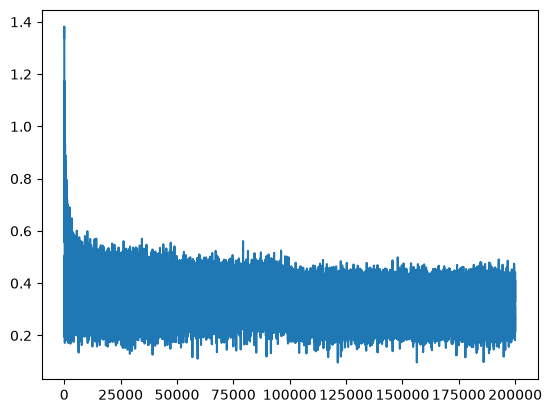

In [154]:
plt.plot(stepi, lossi)

In [155]:
emb = C[Xtr]  # (32, 3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)   # (32, 100)
logits = h @ W2 + b2    # (32, 27)
loss = F.cross_entropy(logits, Ytr)
print(loss.item())

2.094489812850952


In [156]:
emb = C[Xdev]  # (32, 3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)   # (32, 100)
logits = h @ W2 + b2    # (32, 27)
loss = F.cross_entropy(logits, Ydev)
print(loss.item())

2.14776349067688


In [157]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    out = []
    context = [0] * block_size  # intialize with all...
    while True:
        emb = C[torch.tensor([context])]    # (1, block_size, d)
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break

    print(''.join(itos[i] for i in out))

carlah.
amelle.
khy.
mili.
tatyannah.
saeja.
hubn.
den.
art.
kaeli.
nermari.
chaiir.
kaleigh.
ham.
joir.
quinton.
lilah.
jadis.
wayelo.
dearisi.
